# Retrieval-Guided History Selector Post-Training

This notebook post-trains the selected CRF history selector with BM25-derived hard relabels from gold passages, compares it with an epoch-matched Teacher-imitation control, and evaluates Viterbi and FFBS retrieval routes at B64.

### Experimental setup

Notebook 06 inherits the selected `collapsed_crf` checkpoint and retrieval configuration from Notebook 05. SHA-256 checks lock the checkpoint, 600-query sample, architecture decision, and fusion decision to their validated versions.

The base checkpoint is $f_{\mathrm{base}}$ in the thesis. The code IDs `imitation_control` and `bm25_treatment` denote the imitation control $f_{\mathrm{imit}}$ and the corrected-label student $f_{\mathrm{BM25}}$. Both start from $f_{\mathrm{base}}$ and use identical training settings for six additional epochs, giving nine epochs in total. Evaluation is fixed to B64 with two seeded FFBS samples and RRF10 fusion. The final validation records the resolved artifacts, execution flags, and compute device.

In [10]:
from __future__ import annotations

import json
import os
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display


def resolve_project_root(start: Path) -> Path:
    configured = os.environ.get("ROCC_ROOT") or os.environ.get("MASTER_THESIS_PROJECT_ROOT")
    if configured:
        candidate = Path(configured).expanduser().resolve()
        if not (candidate / "experiments" / "rocc").is_dir():
            raise FileNotFoundError(f"Configured ROCC checkout is missing: {candidate}")
        return candidate
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "rocc").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Open this notebook from your ROCC checkout, or set ROCC_ROOT to it. "
        "In Colab, first clone the public repository over HTTPS or authenticate "
        "your own private checkout; no private clone or deploy key is assumed."
    )


PROJECT_ROOT = resolve_project_root(Path.cwd())
os.environ["MASTER_THESIS_PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.rocc import (
    CONTROLLED_POST_TRAINING_ARMS,
    CONTROLLED_POST_TRAINING_RECIPE_VERSION,
    CONTROLLED_POST_TRAINING_ROUTE_ORDER,
    ControlledPostTrainingConfig,
    SelectorExperimentConfig,
    build_selector_oracle_gate,
    compare_controlled_post_training_runs,
    evaluate_controlled_post_training_baseline,
    evaluate_controlled_teacher_targets,
    load_selector_sources,
    materialize_gold_bm25_token_scores,
    prepare_controlled_post_training_datasets,
    prepare_gold_score_selector_dataset,
    prepare_selector_datasets,
    run_controlled_post_training_arm,
    validate_controlled_post_training_inputs,
    validate_selector_environment,
)

SEED = 13
RUN_GOLD_SCORING = True
RUN_CONTROLLED_POST_TRAINING = True
PRIMARY_BUDGET = 64
LOSS_PLOT_UPDATE_EVERY = 50
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

RESULT_DIR = (
    PROJECT_ROOT / "experiments" / "results" / "06_post_training"
)
NB05_RESULT_DIR = (
    PROJECT_ROOT / "experiments" / "results" / "05_history_selector"
)

SELECTOR_CONFIG = SelectorExperimentConfig(
    train_labels=(
        PROJECT_ROOT
        / "experiments/results/04_teacher"
        / "rocc_history_labels_topiocqa_train.jsonl"
    ),
    train_manifest=(
        PROJECT_ROOT
        / "experiments/results/04_teacher"
        / "rocc_history_labels_topiocqa_train.manifest.json"
    ),
    topiocqa_data_dir=(
        PROJECT_ROOT / "experiments/data/topiocqa"
    ),
    result_dir=RESULT_DIR,
    encoding_cache_dir=(
        PROJECT_ROOT / ".cache/master_thesis/05_history_selector"
    ),
    itercqr_model_dir=(
        PROJECT_ROOT / "experiments/model/IterCQR/IterCQR Model"
    ),
    bm25_index_dir=(
        PROJECT_ROOT
        / "experiments/data/pyserini_bm25_lucene_topiocqa"
        / "lucene_index"
    ),
    pipeline_cache_db=(
        PROJECT_ROOT
        / ".cache/master_thesis/03_oracle_headroom_analysis"
        / "runtime_cache.sqlite3"
    ),
    seed=SEED,
    retrieval_workers=max(
        1, min(8, (os.cpu_count() or 2) // 2)
    ),
)

POST_CONFIG = ControlledPostTrainingConfig(
    start_checkpoint=(
        NB05_RESULT_DIR / "full_candidates/collapsed_crf/model.pt"
    ),
    architecture_decision_path=(
        NB05_RESULT_DIR / "train600/architecture/decision.json"
    ),
    fusion_decision_path=(
        NB05_RESULT_DIR / "train600/fusion/decision.json"
    ),
    result_dir=RESULT_DIR,
    expected_start_checkpoint_sha256=(
        "a07271abefbc37ef08dba4eb94adb0e165f53a652060c"
        "069c909a7a1614115c4"
    ),
    expected_vehicle_sample_id_sha256=(
        "147e62c8a7f071356afd7da51dc2b61547837e321a43cb"
        "36e68b5a30f9fef0bb"
    ),
    expected_architecture_decision_sha256=(
        "4794f16088d68d3e937d52b127fcb9433df5232bc9a146"
        "0339eb667db48074d8"
    ),
    expected_fusion_decision_sha256=(
        "da42e86734faa23f6b81aa30aa2c652f50f96cc13c31dc9"
        "d305ea3527349857c"
    ),
    epochs=6,
    batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    gradient_clip_norm=1.0,
    seed=SEED,
    budget=PRIMARY_BUDGET,
    num_ffbs_samples=2,
    sampling_seed=SEED,
    rrf_k=10,
)

# Historical hashes remain the default. ROCC_LINEAGE=local explicitly pins
# matching local upstream files; original method/population checks still run.
from experiments.rocc.paths import bind_notebook_lineage
from dataclasses import replace

local_inputs = bind_notebook_lineage(
    RESULT_DIR, "nb06", {
        "train": SELECTOR_CONFIG.expected_train_sha256,
        "checkpoint": POST_CONFIG.expected_start_checkpoint_sha256,
        "architecture": POST_CONFIG.expected_architecture_decision_sha256,
        "fusion": POST_CONFIG.expected_fusion_decision_sha256,
    }, {
        "train": SELECTOR_CONFIG.train_labels,
        "checkpoint": POST_CONFIG.start_checkpoint,
        "architecture": POST_CONFIG.architecture_decision_path,
        "fusion": POST_CONFIG.fusion_decision_path,
    }, manifest_fields=(
        ("train", SELECTOR_CONFIG.train_manifest, ("dataset_sha256",)),
        ("checkpoint", POST_CONFIG.start_checkpoint.parent / "manifest.json", ("checkpoint_sha256",)),
        ("checkpoint", POST_CONFIG.architecture_decision_path, ("selector_checkpoint_sha256",)),
        ("architecture", POST_CONFIG.fusion_decision_path, ("architecture_decision_sha256",)),
    ),
)
SELECTOR_CONFIG = replace(SELECTOR_CONFIG, expected_train_sha256=local_inputs["train"])
POST_CONFIG = replace(
    POST_CONFIG, expected_start_checkpoint_sha256=local_inputs["checkpoint"],
    expected_architecture_decision_sha256=local_inputs["architecture"],
    expected_fusion_decision_sha256=local_inputs["fusion"],
)

selector_environment = validate_selector_environment(
    SELECTOR_CONFIG,
    require_lora=False,
)
handoff = validate_controlled_post_training_inputs(
    SELECTOR_CONFIG,
    POST_CONFIG,
)
gpu_name = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)
display(
    pd.DataFrame(
        [{
            **selector_environment,
            **handoff,
            "device": DEVICE,
            "gpu": gpu_name,
            "arms": CONTROLLED_POST_TRAINING_ARMS,
            "run_gold_scoring": RUN_GOLD_SCORING,
            "run_controlled_post_training": (
                RUN_CONTROLLED_POST_TRAINING
            ),
        }]
    )
)


,model_name,model_revision,max_position_embeddings,crf_backend,pytorch_crf_version,peft_version,start_checkpoint,start_checkpoint_sha256,architecture_decision_sha256,fusion_decision_sha256,...,training_recipe,epochs,budget,ffbs_samples,candidate_rrf_k,device,gpu,arms,run_gold_scoring,run_controlled_post_training
0,sentence-transformers/all-MiniLM-L12-v2,a50ef00143b4d5391434df20ae11632588ac25be,512,pytorch-crf,0.7.2,None,/experiments/...,a07271abefbc37ef08dba4eb94adb0e165f53a652060c0...,4794f16088d68d3e937d52b127fcb9433df5232bc9a146...,da42e86734faa23f6b81aa30aa2c652f50f96cc13c31dc...,...,hard_relabel_nltk_nostop_controlled_ce_crf_v2,6,64,2,10,cuda:0,NVIDIA GeForce RTX 4070 Laptop GPU,"(imitation_control, bm25_treatment)",True,True


Both post-training arms use the same pinned MiniLM-L12-v2 model, `pytorch-crf` backend, and selected NB05 `collapsed_crf` checkpoint. The checkpoint, architecture decision, and fusion decision pass their SHA-256 lineage checks.

The controlled recipe runs `imitation_control` and `bm25_treatment` for six epochs at B64. Evaluation uses two seeded FFBS samples and fixed RRF10 fusion.

### Preparing the shared post-training data

The Teacher JSONL is verified through its manifest, hashes, row count, and unique IDs before being aligned with reconstructed TopiOCQA histories and positive passages. The fixed depth-balanced procedure then recovers the same 600-query diagnostic population used in Notebooks 03–05, with 100 queries per history-depth bin and one query per conversation.

The pinned MiniLM tokenizer encodes the current query as the first sequence and the dialogue history as the second sequence. History turns are arranged from most recent to oldest, and only the history may be truncated at the 512-WordPiece limit. Character offsets from the validated Teacher spans are projected onto the overlapping history WordPieces. The first WordPiece of a selected region receives `B-KEEP`, its continuation WordPieces receive `I-KEEP`, and the remaining history WordPieces receive `O`. Overlapping Teacher categories form one collapsed KEEP region. Query, special, and padding tokens receive `-100` so that they are excluded from the selector loss.

As an example, consider `train:3198:19`, whose current query is `what is this book about`. The Teacher resolves `this book` through the two most recent history turns and provides the following spans. MiniLM lowercases the text during tokenization.

| Teacher span | Collapsed WordPiece projection |
|---|---|
| `ENTITY`: `The Domesday Book` | `the/B-KEEP domesday/I-KEEP book/I-KEEP` |
| `RELATION_CUE`: `was undertaken in 1086 by William I of England` | `was/B-KEEP undertaken/I-KEEP ... england/I-KEEP` |
| `DEFINITION`: `so that he could properly tax the land he had recently conquered in medieval Europe` | `so/B-KEEP that/I-KEEP ... europe/I-KEEP` |
| `CONCEPT`: `the census data and research` | `the/B-KEEP census/I-KEEP data/I-KEEP and/I-KEEP research/I-KEEP` |
| `KEY_TERM`: `medieval Europe` | Already covered by the longer `DEFINITION` span, so both WordPieces remain `I-KEEP` within the same selected region |

For the same example, the current-query WordPieces `what is this book about` receive `-100`. Unselected history WordPieces such as the T18 question `was it used in medieval europe` and the answer prefix `Yes,` receive `O`. The resulting 512-token encoding contains 504 history WordPieces and 32 KEEP WordPieces.

As in Notebook 05, the collapsed class weights are calculated from the original full-training Teacher labels as

$$
\omega_c=\frac{N_{\mathrm{train}}}{|\mathcal Y|N_{\mathrm{train},c}}
$$

where $N_{\mathrm{train}}$ is the number of supervised history WordPieces, $|\mathcal Y|=3$ is the number of collapsed classes, and $N_{\mathrm{train},c}$ is the count for class $c$. Both post-training arms consequently begin with the same aligned examples, collapsed BIO targets, and class weights before the BM25 treatment is applied.

In [11]:
sources = load_selector_sources(
    SELECTOR_CONFIG,
    include_positive_contexts=True,
    progress=True,
)
train600 = build_selector_oracle_gate(
    sources,
    SELECTOR_CONFIG,
    progress=True,
)

full_sample_ids = [
    str(row["sample_id"])
    for row in sources["train_rows"]
]
train_row_by_id = {
    str(row["sample_id"]): row
    for row in sources["train_rows"]
}
train_sample_by_id = {
    str(sample.sample_id): sample
    for sample in sources["train_samples"]
}
train600_rows = [
    train_row_by_id[sample_id]
    for sample_id in train600.sample_ids
]
train600_samples = [
    train_sample_by_id[sample_id]
    for sample_id in train600.sample_ids
]
train600_gold = {
    sample_id: sources["train_gold_by_sample"][sample_id]
    for sample_id in train600.sample_ids
}

prepared = prepare_selector_datasets(
    sources["train_rows"],
    {
        "full": full_sample_ids,
        "train600": train600.sample_ids,
    },
    SELECTOR_CONFIG,
    class_weight_split="full",
    dataset_sha256=SELECTOR_CONFIG.expected_train_sha256,
    label_spaces=("collapsed",),
    progress=True,
)

display(
    pd.DataFrame(
        [{
            "full_train_queries": len(full_sample_ids),
            "train600_queries": train600.query_count,
            "train600_conversations": (
                train600.conversation_count
            ),
            "train600_sha256": train600.sample_id_sha256,
            "class_weights": [
                round(float(value), 4)
                for value in prepared[
                    "collapsed_class_weights"
                ]
            ],
            "evaluation_scope": "train_member",
        }]
    )
)


,full_train_queries,train600_queries,train600_conversations,train600_sha256,class_weights,evaluation_scope
0,38432,600,600,147e62c8a7f071356afd7da51dc2b61547837e321a43cb...,"[0.3644, 20.9791, 4.8052]",train_member


All 38,432 eligible training queries are prepared for post-training. The 600-query diagnostic population contains 600 distinct conversations and its hash confirms exact agreement with Notebooks 03–05. The fixed class weights correspond to `O`, `B-KEEP`, and `I-KEEP` and are identical to Notebook 05. Results on the 600 queries remain descriptive train-member estimates.

### Gold-passage BM25 token evidence

Gold-BM25 supervision is materialized for all 38,432 training queries to identify history tokens whose lexical terms contribute to matching each query’s known relevant passage. These scores provide the training-only retrieval signal used to correct selected Teacher-DROP labels in the treatment arm. Each query must resolve to exactly one gold passage ID and one matching positive context. The context verifies the passage mapping and provides a content hash, while the lexical scores are calculated from the corresponding document vector in the Lucene BM25 index.

Every whitespace-delimited history word $w$ is processed by the Lucene analyzer. Let $\mathcal A(w)$ contain its analyzed terms $\tau$, using the thesis symbol for a BM25 term. If these terms occur in the gold passage, their BM25 term weights are summed using $k_1=0.9$ and $b=0.4$:

$$
s_{\mathrm{raw}}(w)
=
\sum_{\tau \in \mathcal A(w)}
\operatorname{BM25Weight}(\tau,d_{\mathrm{gold}})
$$

The artifact additionally normalizes positive scores within each query by its largest positive token score (a query without positive evidence remains all zero):

$$
s_{\mathrm{norm}}(w)
=
\frac{s_{\mathrm{raw}}(w)}
{\max_{w'} s_{\mathrm{raw}}(w')}
$$

This normalization is an implementation detail: as in the thesis, only a positive score matters for hard relabeling, not its magnitude.

The resulting JSONL stores the gold passage ID, passage-text hash, token positions, raw scores, and normalized scores. Its configuration and dataset hashes allow completed results to be validated and reused.

The source-token scores are then projected onto the existing MiniLM encoding. Positive stopwords are removed through the embedded NLTK English stopword list, and each remaining positive source token transfers its normalized score to every overlapping visible WordPiece. If several source tokens overlap one WordPiece, the largest score is retained. These aligned positive WordPieces provide the training-only lexical evidence used by the subsequent BM25 hard-relabeling treatment.

In [12]:
if not RUN_GOLD_SCORING:
    raise RuntimeError(
        "The canonical NB06 run requires "
        "RUN_GOLD_SCORING=True."
    )

score_result = materialize_gold_bm25_token_scores(
    rows=sources["train_rows"],
    gold_by_sample=sources["train_gold_by_sample"],
    positive_contexts_by_sample=(
        sources["train_positive_ctxs_by_sample"]
    ),
    selector_config=SELECTOR_CONFIG,
    config=POST_CONFIG,
    progress=True,
)
gold_train_dataset = prepare_gold_score_selector_dataset(
    rows=prepared["rows_by_split"]["full"],
    base_dataset=prepared["collapsed"]["full"],
    tokenizer=prepared["tokenizer"],
    score_result=score_result,
    selector_config=SELECTOR_CONFIG,
    exclude_stopwords=True,
    progress=True,
)

display(
    pd.DataFrame(
        [{
            "reused": score_result.reused,
            "score_dataset_sha256": (
                score_result.dataset_sha256
            ),
            **score_result.stats,
            **{
                f"projected_{key}": value
                for key, value
                in gold_train_dataset.stats.items()
            },
        }]
    )
)

with score_result.path.open("r", encoding="utf-8") as handle:
    score_example = json.loads(next(handle))
example_row = train_row_by_id[str(score_example["sample_id"])]
example_tokens = pd.DataFrame(score_example["tokens"])
display(
    Markdown(
        f"**Example {score_example['sample_id']}** — "
        f"Query: `{example_row['current_query']}`, "
        f"Gold passage: `{score_example['gold_passage_id']}`"
    )
)
display(
    example_tokens.loc[
        example_tokens["score_raw"].gt(0),
        ["turn_id", "field", "text", "score_raw", "score_norm"],
    ].round(4)
)


,reused,score_dataset_sha256,history_tokens,positive_history_token_share,positive_history_tokens,positive_score_max,positive_score_mean,positive_score_median,positive_score_p90,queries,...,queries_without_positive_signal,projected_queries,projected_history_wordpieces,projected_positive_source_tokens,projected_retained_positive_source_tokens,projected_excluded_stopword_source_tokens,projected_stopword_filter,projected_positive_visible_wordpieces,projected_positive_visible_wordpiece_share,projected_queries_without_visible_signal
0,True,329b8841a0e1d8181529e4118c1ae85ccc7ddba716259e...,4932120,0.111182,548361,1.0,0.477513,0.402484,1.0,38432,...,8,38432,7791957,548361,444523,103838,embedded_nltk_english,618799,0.079415,17


**Example train:20:5** — Query: `what critical reception did the former receive`, Gold passage: `13496232`

,turn_id,field,text,score_raw,score_norm
2,1,question,space,2.9541,0.5947
3,1,question,invaders,4.9671,1.0000
5,1,answer,video,2.1051,0.4238
6,1,answer,game,2.3376,0.4706
19,4,question,have,1.0701,0.2154
23,4,answer,Space,2.9541,0.5947
24,4,answer,Invaders,4.9671,1.0000
26,4,answer,Space,2.9541,0.5947
27,4,answer,Invaders,4.9671,1.0000


Across 4,932,120 whitespace-delimited history tokens, 548,361 tokens receive positive BM25 evidence from their query’s gold passage. This corresponds to 11.12% of the source tokens, with only eight queries containing no positive lexical match. Scores are normalized within each query, which gives the strongest token a value of 1.0.

After removing 103,838 positive stopwords, 444,523 positive source tokens remain. Their projection produces 618,799 positive MiniLM WordPieces because one source token may split into several subwords. These WordPieces represent 7.94% of the 7,791,957 visible history WordPieces. Stopword filtering and history truncation increase the number of queries without visible evidence from 8 to 17.

For `train:20:5`, the elliptical query `what critical reception did the former receive` is associated with the gold passage for *Space Invaders*. The history terms `space`, `invaders`, `video`, and `game` receive positive evidence, while `invaders` defines the query-level normalization maximum. The token `have` also has a positive raw BM25 weight but is removed by the stopword filter. The retained terms provide lexical anchors that can connect the unresolved expression `the former` to the intended subject during post-training.

### Controlled BM25 hard relabeling

The control dataset preserves the original Teacher target sequence $\mathbf y^\star$ with labels `O`, `B-KEEP`, and `I-KEEP`. The treatment creates $\mathbf y^\star_{\mathrm{BM25}}$. The treatment dataset starts from the same examples and changes an `O` label to KEEP whenever its visible WordPiece has positive, non-stopword Gold-BM25 evidence. A new selected region begins with `B-KEEP`, while a positive WordPiece immediately following another KEEP label receives `I-KEEP`. Existing Teacher KEEP labels remain unchanged.

The treatment therefore expands the Teacher selection monotonically with lexical evidence from the gold passage. Score magnitude is irrelevant to this hard decision because every projected value above zero triggers the same correction.

Both datasets retain identical input IDs, attention masks, sample order, and NB05 class weights. Separate target hashes document the resulting label sequences. This design isolates the relabeled targets as the only difference between the control and treatment arms.

In [13]:
controlled_datasets = prepare_controlled_post_training_datasets(
    base_full=prepared["collapsed"]["full"],
    base_monitor=prepared["collapsed"]["train600"],
    gold_dataset=gold_train_dataset,
    class_weights=prepared["collapsed_class_weights"],
    score_result=score_result,
    config=POST_CONFIG,
    progress=True,
)

target_manifest = controlled_datasets.manifest
display(
    pd.DataFrame(
        [{
            "queries": target_manifest["queries"],
            "changed_queries": (
                target_manifest["changed_queries"]
            ),
            "changed_query_share": (
                target_manifest["changed_query_share"]
            ),
            "drop_to_keep_wordpieces": (
                target_manifest[
                    "drop_to_keep_wordpiece_flips"
                ]
            ),
            "excluded_stopword_source_tokens": (
                target_manifest[
                    "excluded_stopword_source_tokens"
                ]
            ),
            "teacher_keep_share": (
                target_manifest["teacher_keep_share"]
            ),
            "treatment_keep_share": (
                target_manifest["treatment_keep_share"]
            ),
            "control_target_sha256": (
                target_manifest["control_target_sha256"]
            ),
            "treatment_target_sha256": (
                target_manifest["treatment_target_sha256"]
            ),
            "class_weights_identical": True,
        }]
    ).round(4)
)


,queries,changed_queries,changed_query_share,drop_to_keep_wordpieces,excluded_stopword_source_tokens,teacher_keep_share,treatment_keep_share,control_target_sha256,treatment_target_sha256,class_weights_identical
0,38432,35995,0.9366,395626,103838,0.0853,0.136,3068a0149218ad34b4855c525171449a4596bed89b81f3...,ad1daecefebecfbc816ed0153d7bd433deaf406b8f3d65...,True


BM25 hard relabeling changes at least one target in 35,995 of 38,432 queries, corresponding to 93.66% of the training population. In total, 395,626 visible WordPieces change from `O` to KEEP after 103,838 positive stopword tokens have been excluded.

The KEEP share increases from 8.53% under the original Teacher targets to 13.60% under the treatment targets, an absolute increase of 5.07 percentage points.

### Privileged target-headroom

Before post-training, the two target definitions are evaluated directly to determine whether the BM25 correction contains retrieval-relevant signal. This isolates target construction from the selector’s ability to learn the corrected labels.

For each of the 600 diagnostic queries, positive non-stopword Gold-BM25 tokens are loaded from the full-history score artifact and matched exactly by turn, field, character offsets, and text. The original target retains every source token covered by a Teacher label. The corrected target takes the union of these Teacher tokens and all matched Gold-BM25 tokens. Existing Teacher selections are therefore preserved, while the correction can only add history content.

Consecutive selected source tokens are reconstructed into question and answer fragments for each turn. This construction operates on the complete raw history before MiniLM projection or history truncation. The two resulting history sets are stored as `teacher_original` and `teacher_bm25_corrected` JSONL files. They correspond to original teacher targets $\mathbf y^\star$ and BM25-corrected targets $\mathbf y^\star_{\mathrm{BM25}}$ in the thesis; this direct target comparison precedes student prediction.

Both histories are then evaluated through the same frozen B64 retrieval pipeline. The current query and selected history are serialized in recent-first order, rewritten by IterCQR, and retrieved with BM25 up to rank 1000. The original Teacher route must reproduce the frozen Notebook 04 metrics exactly, which verifies that the evaluation path has remained unchanged.

For each query, we subtract the original-target metric from the corrected-target metric. The paired mean MRR difference is therefore corrected minus original, as in the thesis.

Mean differences and 95% paired bootstrap intervals are reported for MRR, nDCG@3, $\mathrm{Recall}@10$, $\mathrm{Recall}@100$, and $\mathrm{Recall}@1000$. Selection statistics additionally quantify retained source tokens, mean selected words, empty histories, and KEEP share.

Since the corrected history uses privileged evidence from each query’s gold passage, this comparison measures the retrieval headroom of the hard-relabeling rule itself. The following controlled post-training experiment tests how much of that target-level signal can be learned by the CRF selector.

In [14]:
target_headroom = evaluate_controlled_teacher_targets(
    rows=train600_rows,
    samples=train600_samples,
    gold_by_sample=train600_gold,
    score_result=score_result,
    selector_config=SELECTOR_CONFIG,
    config=POST_CONFIG,
    device=DEVICE,
    progress=True,
)

display(target_headroom["selection_summary"].round(4))
display(
    target_headroom["summary"]
    .sort_values("arm", kind="mergesort")
    .round(4)
)
display(
    target_headroom["comparisons"].round(4)
)


,arm,queries,history_tokens,keep_tokens,mean_selected_words,empty_selections,keep_share
0,teacher_original,600,96218,8620,14.3667,0,0.0896
1,teacher_bm25_corrected,600,96218,13747,22.9117,0,0.1429


,budget,arm,n,MRR,nDCG@3,R@10,R@100,R@1000
0,64,teacher_bm25_corrected,600,0.2856,0.2816,0.4300,0.6483,0.8100
1,64,teacher_original,600,0.1704,0.1607,0.2917,0.5033,0.6667


,budget,metric,comparison,left_arm,right_arm,n,delta,ci95_low,ci95_high,seed,replicates
0,64,MRR,teacher_bm25_corrected - teacher_original,teacher_bm25_corrected,teacher_original,600,0.1152,0.0905,0.1405,30,10000
1,64,nDCG@3,teacher_bm25_corrected - teacher_original,teacher_bm25_corrected,teacher_original,600,0.1209,0.0940,0.1484,31,10000
2,64,R@10,teacher_bm25_corrected - teacher_original,teacher_bm25_corrected,teacher_original,600,0.1383,0.1033,0.1733,32,10000
3,64,R@100,teacher_bm25_corrected - teacher_original,teacher_bm25_corrected,teacher_original,600,0.1450,0.1083,0.1817,33,10000
4,64,R@1000,teacher_bm25_corrected - teacher_original,teacher_bm25_corrected,teacher_original,600,0.1433,0.1100,0.1767,34,10000


The BM25 treatment changes 395,626 WordPiece targets across 35,995 of the 38,432 training queries. This raises the full-training KEEP share from 8.53% to 13.60% while preserving every original Teacher KEEP label and the NB05 class weights.

Within the 600-query diagnostic population, the corrected target retains an average of 22.91 words per query compared with 14.37 for the original Teacher target. Its KEEP share rises from 8.96% to 14.29%, and both target definitions produce a non-empty history for every query.

The original target reproduces the Notebook 04 B64 MRR of 0.1704. Adding the non-stopword Gold-BM25 tokens increases MRR to 0.28558, a paired gain of 0.11523 with a 95% confidence interval of [0.09052, 0.14054]. Improvements are also supported for nDCG@3 and every recall cutoff. $\mathrm{Recall}@1000$ rises from 0.6667 to 0.8100, corresponding to a gain of 0.1433 with a 95% confidence interval of [0.1100, 0.1767].

Since the corrected targets are constructed from each query’s gold passage, these results quantify privileged target-level headroom. They establish that the added lexical labels contain substantial retrieval signal. The controlled post-training comparison next tests whether the CRF selector can learn this signal beyond continued training on the original Teacher targets.

### Baseline

The selected NB05 `collapsed_crf` checkpoint, $f_{\mathrm{base}}$, is loaded as the additional-epoch-zero reference for both post-training arms. Its KEEP predictions are first compared with the original Teacher BIO labels on the 600 train-member queries. These label metrics establish the starting point from which subsequent changes in CRF behavior are measured.

The same checkpoint then generates three history candidates for every query. Viterbi decoding returns the highest-scoring CRF sequence. Two additional sequences are drawn independently with replacement from $p_{\mathrm{CRF}}(\mathbf y\mid\mathbf U)$ through forward-filtering backward-sampling (FFBS). They may coincide with one another or with the Viterbi sequence $\hat{\mathbf y}$. A fixed global random stream with seed 13 reuses the same uniform random numbers for every arm and epoch, which makes later trajectory comparisons paired and reproducible without requiring the resulting label sequences to match.

Each selected history is evaluated through the B64 `ROCC → IterCQR → BM25` route. The resulting Viterbi, `sample_1`, and `sample_2` rankings are combined into two fixed retrieval routes. `ffbs2_rrf10` fuses the two sampled rankings, while `viterbi_ffbs2_rrf10` fuses Viterbi with both samples. Reciprocal-rank fusion uses

$$
\operatorname{RRF}_{\kappa}(d)
=\sum_{\substack{L\in\mathcal R\\d\in L}}
\frac{1}{\kappa+\operatorname{rank}_L(d)},\qquad \kappa=10.
$$

Here, $\mathcal R$ is the collection of participating candidate rankings, with one-based ranks. A list contributes only when it contains passage $d$. The development implementation retains each candidate list, including coincident outputs.

The route summary reports retrieval quality for standalone Viterbi and both fused variants. Union recall separately measures whether any of the three underlying candidate rankings retrieves a gold passage at ranks 10, 100, or 1000. The hit-pattern table shows whether that success comes from Viterbi, either FFBS sample, or a combination of candidates.

This epoch-zero evaluation fixes the retrieval and CRF-sampling baseline before continued Teacher imitation and BM25-corrected post-training begin.

In [15]:
baseline = evaluate_controlled_post_training_baseline(
    rows=train600_rows,
    samples=train600_samples,
    gold_by_sample=train600_gold,
    monitor_dataset=controlled_datasets.control_monitor,
    tokenizer=prepared["tokenizer"],
    class_weights=controlled_datasets.class_weights,
    selector_config=SELECTOR_CONFIG,
    config=POST_CONFIG,
    device=DEVICE,
    progress=True,
)

display(
    pd.DataFrame(
        [{
            "system": "pretrained",
            "epoch": 0,
            **baseline["label_metrics"],
        }]
    ).round(4)
)
display(
    baseline["evaluation"]["summary"].round(4)
)
display(
    baseline["evaluation"]["union_summary"].round(4)
)
display(
    baseline["evaluation"]["union_patterns"].round(4)
)


,system,epoch,token_accuracy,keep_precision,keep_recall,keep_f1,keep_tp,keep_fp,keep_fn,token_correct,token_total,span_precision,span_recall,span_f1,loss
0,pretrained,0,0.947,0.6111,0.8834,0.7224,9766,6216,1289,141356,149260,0.2904,0.5776,0.3865,0.3459


,route,n,MRR,nDCG@3,R@10,R@100,R@1000
0,ffbs2_rrf10,600,0.1596,0.1364,0.3083,0.5167,0.7300
1,viterbi,600,0.1656,0.1509,0.2850,0.5017,0.6817
2,viterbi_ffbs2_rrf10,600,0.1754,0.1562,0.3217,0.5500,0.7467


,cutoff,n,viterbi_recall,sample_1_recall,sample_2_recall,union_recall,union_gain_vs_best_single
0,10,600,0.2850,0.2767,0.2483,0.3817,0.0967
1,100,600,0.5017,0.4617,0.4750,0.5950,0.0933
2,1000,600,0.6817,0.6800,0.6600,0.8033,0.1217


,cutoff,hit_pattern,count,share
0,10,neither,371,0.6183
1,10,sample_1,28,0.0467
2,10,sample_1+sample_2,10,0.0167
3,10,sample_2,20,0.0333
4,10,viterbi,26,0.0433
5,10,viterbi+sample_1,26,0.0433
6,10,viterbi+sample_1+sample_2,102,0.1700
7,10,viterbi+sample_2,17,0.0283
8,100,neither,243,0.4050
9,100,sample_1,15,0.0250


The unchanged NB05 checkpoint reproduces its $F_1^{\mathrm{KEEP}}$ of 0.7224 on the 600 train-member queries. KEEP recall is high at 0.8834, while precision is 0.6111. The selector therefore retains most Teacher-labeled WordPieces while also selecting additional history content. Exact span-boundary agreement is harder, as reflected by the lower $F_1^{\mathrm{span}}$ of 0.3865.

Viterbi decoding reproduces the NB05 B64 MRR of 0.1656. Fusing the two FFBS rankings alone yields an MRR of 0.1596 but increases recall at every cutoff. Combining Viterbi with both FFBS rankings through RRF10 achieves the strongest baseline route with an MRR of 0.1754 and $\mathrm{Recall}@1000$ of 0.7467. The sampled CRF sequences therefore contribute retrieval evidence that is complementary to the highest-scoring Viterbi sequence.

The candidate union reaches 0.3817 recall at rank 10, 0.5950 at rank 100, and 0.8033 at rank 1000. These values exceed the best individual candidate by 0.0967, 0.0933, and 0.1217 respectively. Route-exclusive and partially overlapping hit patterns confirm that Viterbi and the two FFBS samples retrieve different relevant passages. This establishes the fixed epoch-zero reference for measuring how each post-training arm changes both the central CRF prediction and its surrounding sequence distribution.

### Controlled post-training

`imitation_control` and `bm25_treatment` are initialized independently from the same NB05 checkpoint. Both optimize the unchanged objective

$$
\mathcal L_{\mathrm{CE}}+\mathcal L_{\mathrm{CRF}}/r
$$

with coefficient 1 for each term. Here, $\mathcal L_{\mathrm{CE}}$ is class-weighted token cross-entropy, $\mathcal L_{\mathrm{CRF}}=-\log p_{\mathrm{CRF}}(\mathbf y^\star\mid\mathbf U)$ is the sequence negative log-likelihood, and $r$ is the visible history-token count. Each sequence loss is divided by its own $r$ before the batch mean. For $f_{\mathrm{BM25}}$, the target is $\mathbf y^\star_{\mathrm{BM25}}$ instead of $\mathbf y^\star$. Class weights, optimizer, linear learning-rate schedule, seed, minibatch order, and all remaining training settings are identical. The only experimental difference is the target sequence. The control retains the original Teacher BIO labels, while the treatment adds the Gold-BM25 hard relabels.

After every epoch, the CRF distribution is decoded through three B64 retrieval routes. Viterbi returns the highest-scoring complete BIO sequence. FFBS draws two additional complete sequences independently with replacement from $p_{\mathrm{CRF}}(\mathbf y\mid\mathbf U)$. Each sequence supplies a selected history to IterCQR and BM25; different draws can produce the same history or coincide with Viterbi.

`ffbs2_rrf10` fuses the rankings produced by the two sampled histories. `viterbi_ffbs2_rrf10` combines both samples with the Viterbi route. Reciprocal-rank fusion assigns each document the score

$$
\operatorname{RRF}_{\kappa}(d)
=\sum_{\substack{L\in\mathcal R\\d\in L}}
\frac{1}{\kappa+\operatorname{rank}_L(d)},\qquad \kappa=10.
$$

where $\mathcal R$ contains the participating candidate rankings and ranks start at 1. Only rankings containing $d$ contribute; this development calculation retains each candidate ranking. FFBS exposes alternative history selections to which the CRF assigns probability mass, while Viterbi represents its single most likely selection. Their fusion tests whether this structured uncertainty provides complementary retrieval evidence. FFBS affects inference and evaluation only, while both arms retain the same training objective.

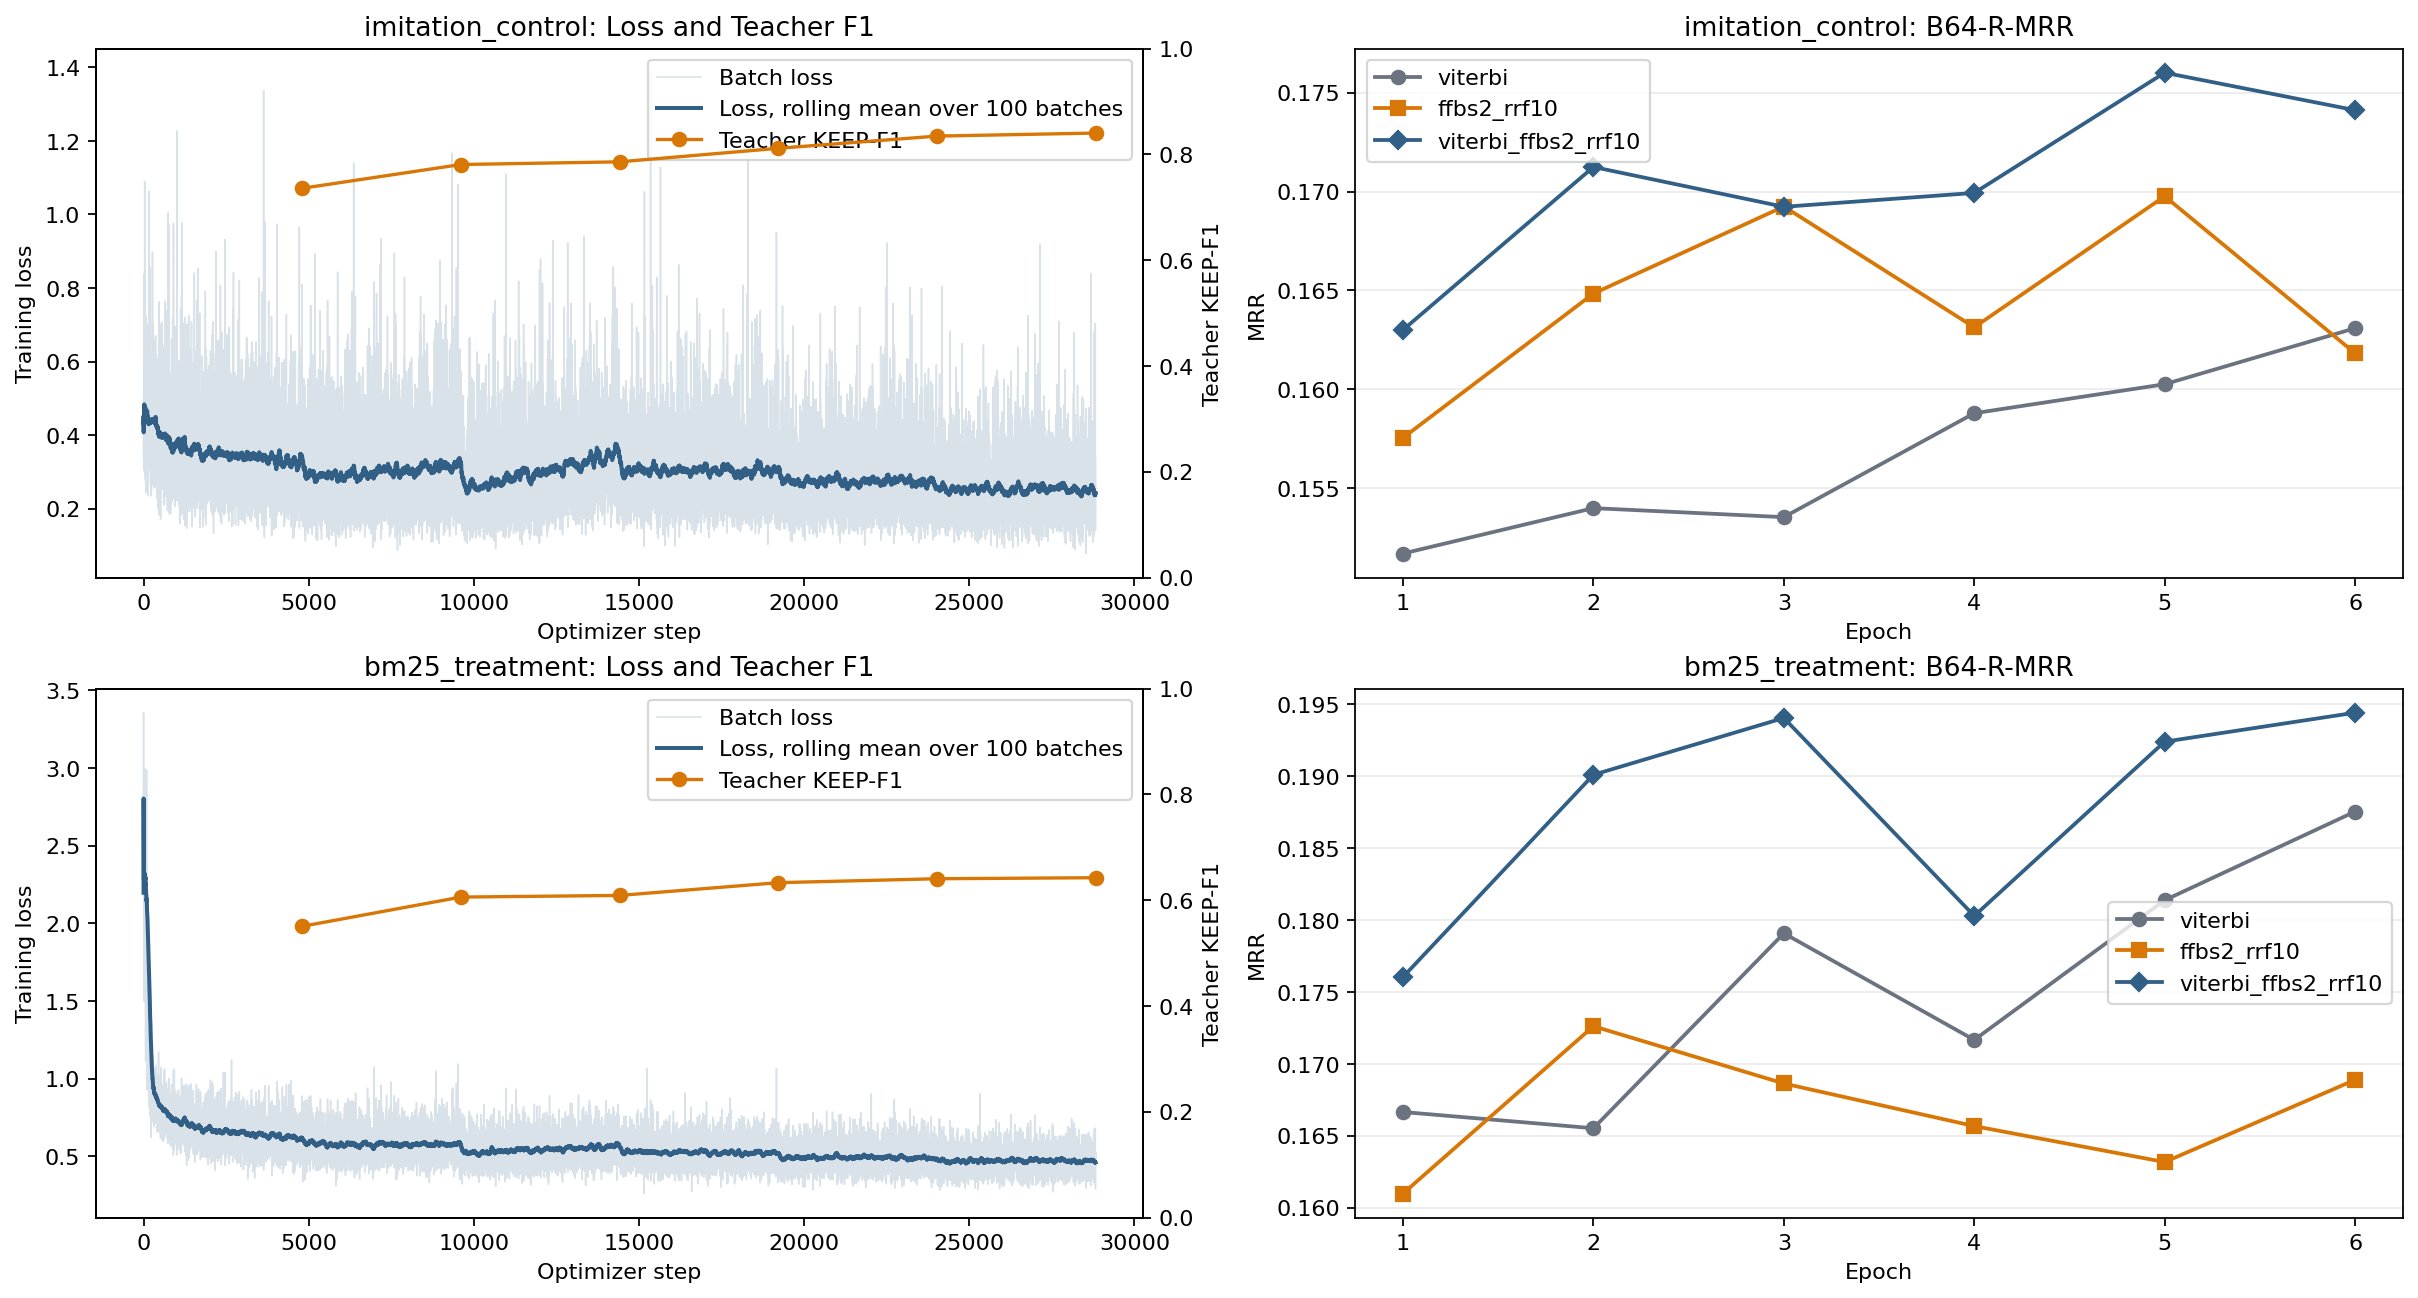

In [ ]:
class ControlledPostTrainingDashboard:
    def __init__(self, arms: tuple[str, ...]) -> None:
        self.arms = arms
        self.loss_rows = {arm: [] for arm in arms}
        self.epoch_rows = {arm: [] for arm in arms}
        self.figure, axes = plt.subplots(
            len(arms),
            2,
            figsize=(15, 8),
            constrained_layout=True,
            squeeze=False,
        )
        self.axes = {
            arm: (axes[index, 0], axes[index, 1])
            for index, arm in enumerate(arms)
        }
        self.f1_axes = {
            arm: self.axes[arm][0].twinx()
            for arm in arms
        }
        self.handle = display(
            self.figure,
            display_id=True,
        )
        plt.close(self.figure)
        for arm in arms:
            self._draw(arm, update=False)
        self.handle.update(self.figure)

    def on_batch(
        self,
        arm: str,
        row: dict[str, Any],
    ) -> None:
        self.loss_rows[arm].append(dict(row))
        if int(row["batch"]) % LOSS_PLOT_UPDATE_EVERY == 0:
            self._draw(arm)

    def on_epoch(
        self,
        arm: str,
        row: dict[str, Any],
    ) -> None:
        self.epoch_rows[arm].append(dict(row))
        self._draw(arm)

    def load_history(
        self,
        arm: str,
        loss_history: pd.DataFrame,
        epoch_metrics: pd.DataFrame,
    ) -> None:
        self.loss_rows[arm] = loss_history.to_dict(
            orient="records"
        )
        self.epoch_rows[arm] = epoch_metrics.to_dict(
            orient="records"
        )
        self._draw(arm)

    def _draw(
        self,
        arm: str,
        *,
        update: bool = True,
    ) -> None:
        loss_axis, mrr_axis = self.axes[arm]
        f1_axis = self.f1_axes[arm]
        loss_axis.clear()
        f1_axis.clear()
        mrr_axis.clear()

        loss_frame = pd.DataFrame(self.loss_rows[arm])
        epoch_frame = pd.DataFrame(self.epoch_rows[arm])
        if not loss_frame.empty:
            loss_frame = loss_frame.sort_values(
                "global_step",
                kind="mergesort",
            )
            loss_axis.plot(
                loss_frame["global_step"],
                loss_frame["loss"],
                color="#315f86",
                alpha=0.18,
                linewidth=0.7,
                label="Batch loss",
            )
            loss_axis.plot(
                loss_frame["global_step"],
                loss_frame["loss"]
                .rolling(100, min_periods=1)
                .mean(),
                color="#315f86",
                linewidth=1.8,
                label="Loss, rolling mean over 100 batches",
            )

        if not epoch_frame.empty:
            epoch_frame = epoch_frame.sort_values(
                "epoch",
                kind="mergesort",
            )
            if not loss_frame.empty:
                step_by_epoch = loss_frame.groupby("epoch")[
                    "global_step"
                ].max()
                f1_steps = [
                    int(step_by_epoch.loc[int(epoch)])
                    for epoch in epoch_frame["epoch"]
                ]
            else:
                f1_steps = epoch_frame["epoch"].tolist()
            f1_axis.plot(
                f1_steps,
                epoch_frame["keep_f1"],
                color="#d97706",
                marker="o",
                linewidth=1.5,
                label="Teacher KEEP-F1",
            )
            route_styles = {
                "viterbi": ("#6b7280", "o"),
                "ffbs2_rrf10": ("#d97706", "s"),
                "viterbi_ffbs2_rrf10": ("#315f86", "D"),
            }
            for route, (color, marker) in route_styles.items():
                column = f"train600_{route}_MRR"
                if column in epoch_frame:
                    mrr_axis.plot(
                        epoch_frame["epoch"],
                        epoch_frame[column],
                        color=color,
                        marker=marker,
                        linewidth=1.7,
                        label=route,
                    )

        loss_axis.set_title(f"{arm}: Loss and Teacher F1")
        loss_axis.set_xlabel("Optimizer step")
        loss_axis.set_ylabel("Training loss")
        f1_axis.set_ylabel("Teacher KEEP-F1")
        f1_axis.set_ylim(0.0, 1.0)
        handles_left, labels_left = (
            loss_axis.get_legend_handles_labels()
        )
        handles_right, labels_right = (
            f1_axis.get_legend_handles_labels()
        )
        if handles_left or handles_right:
            loss_axis.legend(
                handles_left + handles_right,
                labels_left + labels_right,
                loc="best",
            )

        mrr_axis.set_title(f"{arm}: B64-R-MRR")
        mrr_axis.set_xlabel("Epoch")
        mrr_axis.set_ylabel("MRR")
        mrr_axis.grid(axis="y", alpha=0.25)
        if mrr_axis.get_legend_handles_labels()[0]:
            mrr_axis.legend(loc="best")
        if update:
            self.handle.update(self.figure)

    def save(self, path: Path) -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        self.figure.savefig(
            path,
            dpi=160,
            bbox_inches="tight",
        )


if not RUN_CONTROLLED_POST_TRAINING:
    raise RuntimeError(
        "The canonical NB06 run requires "
        "RUN_CONTROLLED_POST_TRAINING=True."
    )

training_dashboard = ControlledPostTrainingDashboard(
    CONTROLLED_POST_TRAINING_ARMS
)


$F_1^{\mathrm{KEEP}}$ and MRR answer different questions. The models optimize sequence-label imitation through the weighted CE–CRF objective. MRR is never part of the training loss. It is measured only after each epoch by passing the predicted history through IterCQR and BM25.

`imitation_control` reduces its loss from 0.358 to 0.253 and increases Teacher $F_1^{\mathrm{KEEP}}$ from 0.736 to 0.84. This directly shows improved imitation of the original Teacher labels. Its combined B64 retrieval route remains close to the pretrained reference of 0.1754 MRR, reaching 0.1760 at epoch 5 and 0.1741 at epoch 6. Better label imitation alone therefore produces no corresponding retrieval improvement.

`bm25_treatment` reduces its loss from 0.726 to 0.471 while learning the corrected targets. The displayed Teacher $F_1^{\mathrm{KEEP}}$ remains evaluated against the original Teacher labels and therefore measures how much of the original policy is retained. It rises from 0.551 to 0.643. In parallel, the combined retrieval route increases from 0.1760 to 0.1944 MRR, while Viterbi MRR reaches 0.1875 at epoch 6.

The treatment does not control MRR directly. It changes the imitation targets using Gold-BM25 evidence and tests whether this retrieval-oriented signal can be learned well enough to improve the downstream pipeline. The stronger treatment MRR supports this hypothesis on the 600 train-member queries. The combined Viterbi and FFBS route provides the strongest final B64 result.

### Controlled post-training comparison

`imitation_control` and `bm25_treatment` are trained independently from the same NB05 checkpoint with identical class weights, optimizer settings, seed, minibatch order, and six-epoch schedule. The control retains the original Teacher targets, while the treatment uses the Gold-BM25-corrected targets. This control is required because comparing the treatment directly with NB05 would mix the effect of additional training with the effect of relabeling. The treatment-minus-control difference therefore isolates the contribution of the corrected targets.

In [ ]:
post_runs = {}
post_runs["imitation_control"] = (
    run_controlled_post_training_arm(
        arm="imitation_control",
        datasets=controlled_datasets,
        rows=train600_rows,
        samples=train600_samples,
        gold_by_sample=train600_gold,
        tokenizer=prepared["tokenizer"],
        selector_config=SELECTOR_CONFIG,
        config=POST_CONFIG,
        device=DEVICE,
        batch_metrics_reporter=(
            training_dashboard.on_batch
        ),
        epoch_metrics_reporter=(
            training_dashboard.on_epoch
        ),
        history_reporter=(
            training_dashboard.load_history
        ),
        progress=True,
    )
)

control_run = post_runs["imitation_control"]

post_runs["bm25_treatment"] = (
    run_controlled_post_training_arm(
        arm="bm25_treatment",
        datasets=controlled_datasets,
        rows=train600_rows,
        samples=train600_samples,
        gold_by_sample=train600_gold,
        tokenizer=prepared["tokenizer"],
        selector_config=SELECTOR_CONFIG,
        config=POST_CONFIG,
        device=DEVICE,
        batch_metrics_reporter=(
            training_dashboard.on_batch
        ),
        epoch_metrics_reporter=(
            training_dashboard.on_epoch
        ),
        history_reporter=(
            training_dashboard.load_history
        ),
        progress=True,
    )
)
training_dashboard.save(
    POST_CONFIG.experiment_dir
    / "training"
    / "loss_f1_and_mrr_live.png"
)

training_rows = []
for arm in CONTROLLED_POST_TRAINING_ARMS:
    run = post_runs[arm]
    final_epoch = run["epoch_metrics"].iloc[-1]
    training_rows.append(
        {
            "arm": arm,
            "reused": run["reused"],
            "epochs": POST_CONFIG.epochs,
            "final_train_loss": float(
                final_epoch["train_loss"]
            ),
            "final_keep_f1": float(
                final_epoch["keep_f1"]
            ),
            "final_viterbi_MRR": float(
                final_epoch[
                    "train600_viterbi_MRR"
                ]
            ),
            "final_ffbs2_MRR": float(
                final_epoch[
                    "train600_ffbs2_rrf10_MRR"
                ]
            ),
            "final_k3_MRR": float(
                final_epoch[
                    "train600_viterbi_ffbs2_rrf10_MRR"
                ]
            ),
            "checkpoint_sha256": (
                run["checkpoint_sha256"]
            ),
            "duration_seconds": (
                run["run"].duration_seconds
            ),
        }
    )
display(pd.DataFrame(training_rows).round(4))


,arm,reused,epochs,final_train_loss,final_keep_f1,final_viterbi_MRR,final_ffbs2_MRR,final_k3_MRR,checkpoint_sha256,duration_seconds
0,imitation_control,True,6,0.2531,0.8404,0.1631,0.1618,0.1741,7734e22b1b6682701d928d44c1a22ae4bd0703248ec521...,9198.6161
1,bm25_treatment,True,6,0.4708,0.6426,0.1875,0.1689,0.1944,72d1cf90227e5829eda0ca4716ac642ab137f74177ee06...,9056.7588


`imitation_control` reaches Teacher $F_1^{\mathrm{KEEP}}$ 0.8404 because it trains and evaluates against the original Teacher labels. `bm25_treatment` reaches 0.6426 because it learns additional BM25-derived KEEP targets while $F_1^{\mathrm{KEEP}}$ retains the original Teacher labels as its reference.

The treatment improves Viterbi MRR by +0.02443, FFBS2 MRR by +0.0071, and combined MRR by +0.0203 over the control. Both arms share the same checkpoint initialization and training configuration, so the changed target labels explain this difference. The corrected-label model reaches a final combined MRR of 0.1944 on these training-member queries. This is evidence about downstream retrieval, not a separate measurement of rewrite correctness.

### Comparing post-training trajectories

The comparison reconstructs MRR from the shared NB05 checkpoint at epoch 0 through epochs 1–6 for both arms and all three decoding routes. At the fixed epoch-6 endpoint, it calculates each query’s MRR difference between treatment, control, and pretrained model. A paired bootstrap over the same 600 queries produces 95% confidence intervals.

This design separates the sources of change. `control − pretrained` measures the effect of six additional training epochs. `treatment − control` measures the effect of Gold-BM25 relabeling because training conditions are otherwise identical. `treatment − pretrained` measures their combined effect. Fixing epoch 6 prevents selection of the most favorable intermediate result, while query pairing controls for differences in query difficulty.

,system,epoch,route,n,MRR,nDCG@3,R@10,R@100,R@1000
21,bm25_treatment,1,ffbs2_rrf10,600,0.1610,0.1478,0.2683,0.4883,0.6950
24,bm25_treatment,2,ffbs2_rrf10,600,0.1726,0.1585,0.2867,0.4900,0.7300
27,bm25_treatment,3,ffbs2_rrf10,600,0.1686,0.1543,0.3000,0.5150,0.7167
30,bm25_treatment,4,ffbs2_rrf10,600,0.1657,0.1497,0.2967,0.5067,0.7333
33,bm25_treatment,5,ffbs2_rrf10,600,0.1632,0.1479,0.2950,0.4867,0.7200
36,bm25_treatment,6,ffbs2_rrf10,600,0.1689,0.1533,0.3017,0.5000,0.7283
3,imitation_control,1,ffbs2_rrf10,600,0.1575,0.1418,0.2933,0.4983,0.7250
6,imitation_control,2,ffbs2_rrf10,600,0.1648,0.1522,0.2867,0.5150,0.7133
9,imitation_control,3,ffbs2_rrf10,600,0.1692,0.1543,0.2983,0.5150,0.7133
12,imitation_control,4,ffbs2_rrf10,600,0.1631,0.1470,0.2917,0.5217,0.7167


,registered_comparison,route,budget,metric,comparison,left_arm,right_arm,n,delta,ci95_low,ci95_high,seed,replicates
0,treatment_minus_control,viterbi,64,MRR,bm25_treatment - imitation_control,bm25_treatment,imitation_control,600,0.0244,0.0052,0.0439,13,10000
1,treatment_minus_control,ffbs2_rrf10,64,MRR,bm25_treatment - imitation_control,bm25_treatment,imitation_control,600,0.0071,-0.0115,0.0260,14,10000
2,treatment_minus_control,viterbi_ffbs2_rrf10,64,MRR,bm25_treatment - imitation_control,bm25_treatment,imitation_control,600,0.0203,0.0004,0.0413,15,10000
3,control_minus_pretrained,viterbi,64,MRR,imitation_control - pretrained,imitation_control,pretrained,600,-0.0026,-0.0178,0.0124,16,10000
4,control_minus_pretrained,ffbs2_rrf10,64,MRR,imitation_control - pretrained,imitation_control,pretrained,600,0.0022,-0.0143,0.0188,17,10000
5,control_minus_pretrained,viterbi_ffbs2_rrf10,64,MRR,imitation_control - pretrained,imitation_control,pretrained,600,-0.0013,-0.0157,0.0132,18,10000
6,treatment_minus_pretrained,viterbi,64,MRR,bm25_treatment - pretrained,bm25_treatment,pretrained,600,0.0219,0.0024,0.0416,19,10000
7,treatment_minus_pretrained,ffbs2_rrf10,64,MRR,bm25_treatment - pretrained,bm25_treatment,pretrained,600,0.0092,-0.0103,0.0288,20,10000
8,treatment_minus_pretrained,viterbi_ffbs2_rrf10,64,MRR,bm25_treatment - pretrained,bm25_treatment,pretrained,600,0.0190,0.0004,0.0381,21,10000


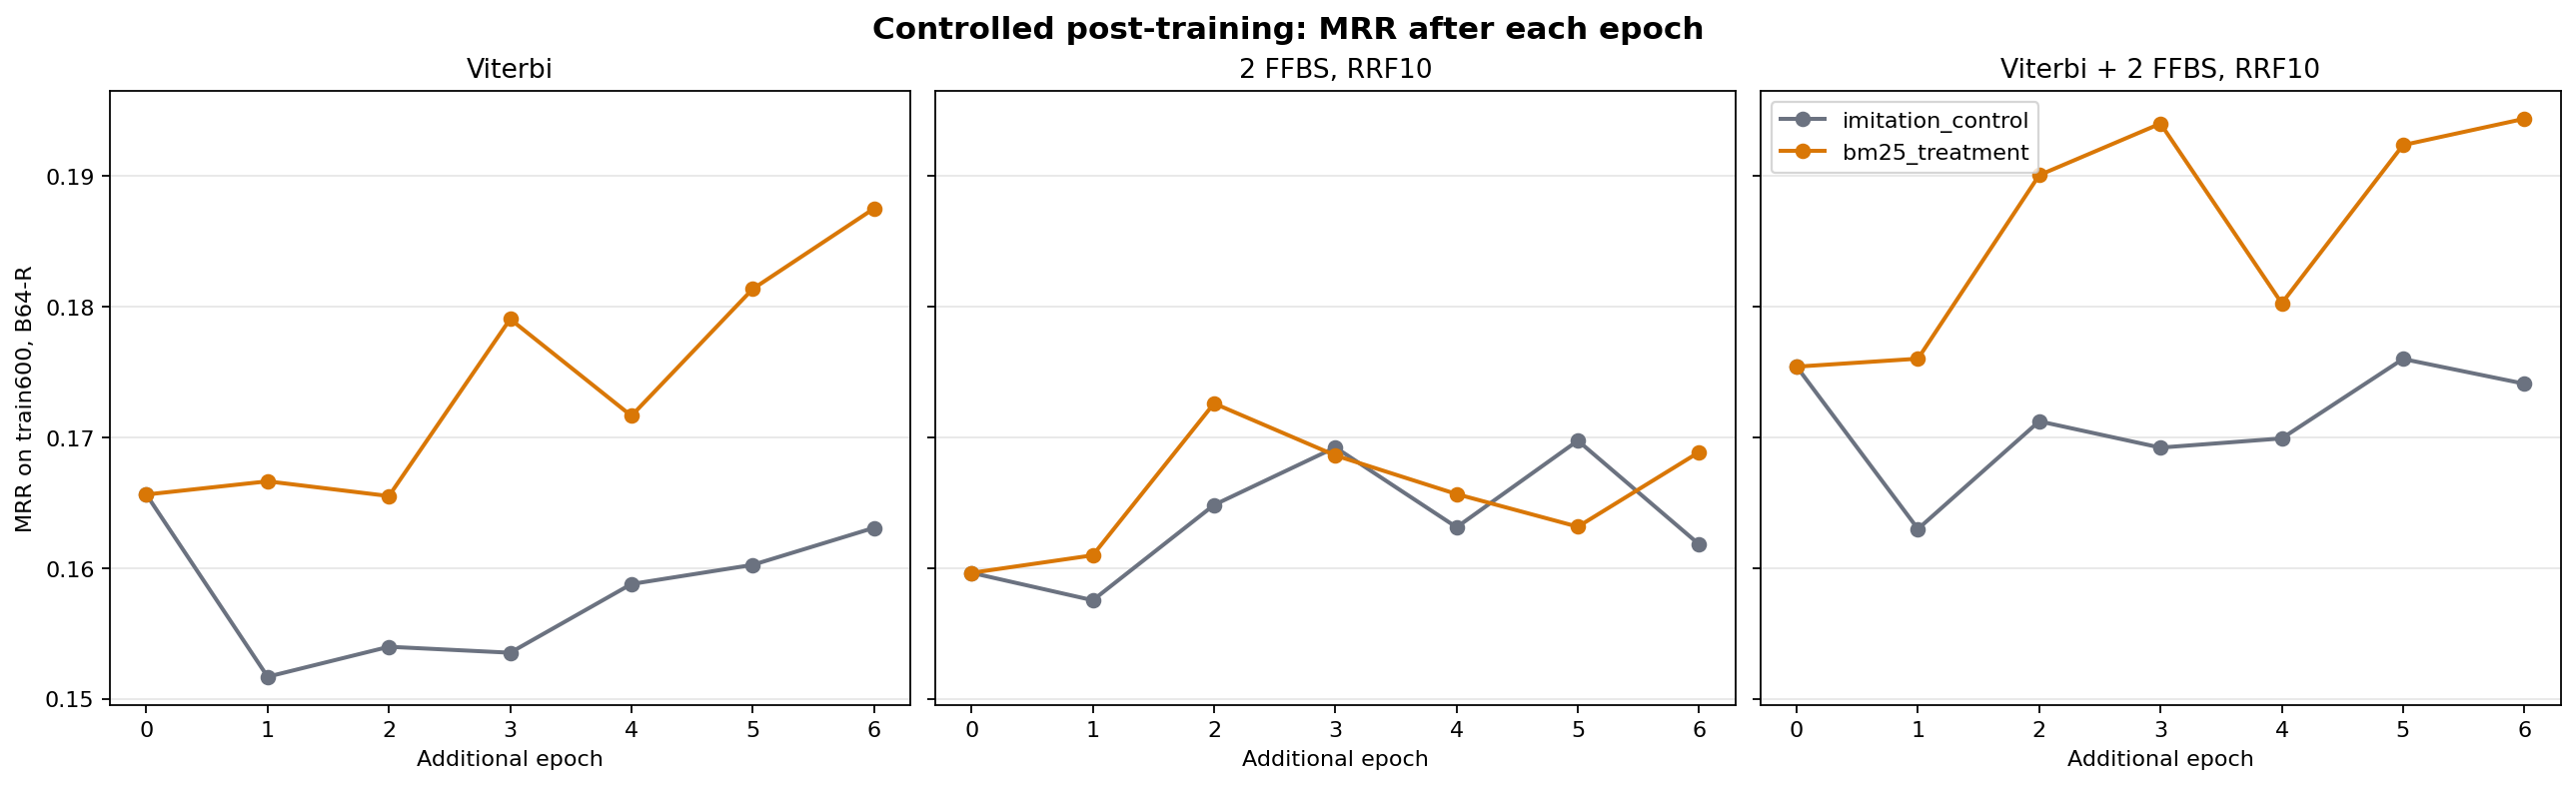

Plot: <project>/experiments/results/06_post_training/controlled_hard_relabel_nostop_e6/comparison/mrr_trajectories_epoch_0_6.png


In [10]:
comparison = compare_controlled_post_training_runs(
    baseline=baseline,
    runs=post_runs,
    datasets=controlled_datasets,
    selector_config=SELECTOR_CONFIG,
    config=POST_CONFIG,
    progress=True,
)

display(
    comparison["trajectory"]
    .sort_values(
        ["route", "system", "epoch"],
        kind="mergesort",
    )
    .round(4)
)
display(comparison["comparisons"].round(4))

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#39424e",
        "axes.labelcolor": "#20262e",
        "axes.titlecolor": "#20262e",
        "grid.color": "#d9dee5",
        "font.size": 10,
    }
)
trajectory = comparison["trajectory"]
baseline_by_route = (
    trajectory.loc[
        trajectory["system"].eq("pretrained")
    ]
    .set_index("route")["MRR"]
)
route_titles = {
    "viterbi": "Viterbi",
    "ffbs2_rrf10": "2 FFBS, RRF10",
    "viterbi_ffbs2_rrf10": "Viterbi + 2 FFBS, RRF10",
}
arm_colors = {
    "imitation_control": "#6b7280",
    "bm25_treatment": "#d97706",
}
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
    constrained_layout=True,
    sharey=True,
)
for axis, route in zip(
    axes,
    CONTROLLED_POST_TRAINING_ROUTE_ORDER,
    strict=True,
):
    for arm in CONTROLLED_POST_TRAINING_ARMS:
        selected = trajectory.loc[
            trajectory["system"].eq(arm)
            & trajectory["route"].eq(route)
        ].sort_values("epoch", kind="mergesort")
        epochs = [0, *selected["epoch"].astype(int).tolist()]
        values = [
            float(baseline_by_route.loc[route]),
            *selected["MRR"].astype(float).tolist(),
        ]
        axis.plot(
            epochs,
            values,
            marker="o",
            linewidth=1.8,
            color=arm_colors[arm],
            label=arm,
        )
    axis.set_title(route_titles[route])
    axis.set_xlabel("Additional epoch")
    axis.set_xticks(range(0, POST_CONFIG.epochs + 1))
    axis.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("MRR on train600, B64-R")
axes[-1].legend(loc="best")
fig.suptitle(
    "Controlled post-training: MRR after each epoch",
    fontsize=14,
    fontweight="bold",
)
plot_path = (
    POST_CONFIG.experiment_dir
    / "comparison"
    / "mrr_trajectories_epoch_0_6.png"
)
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Plot:", plot_path)


Additional Teacher imitation produces no statistically resolved retrieval change at epoch 6. Relative to the pretrained checkpoint, the control differences are −0.0026 for Viterbi, +0.0022 for FFBS2, and −0.0013 for the combined route. All three confidence intervals contain zero. Six additional training epochs therefore do not explain the treatment gains.

Gold-BM25 relabeling improves Viterbi MRR over the control by +0.02443 with a 95% CI of [+0.00523, +0.04392]. The combined Viterbi–FFBS route improves by +0.0203 with a 95% CI of [+0.0004, +0.0413]. FFBS2 alone improves by +0.0071, but its interval [−0.0115, +0.0260] contains zero.

The evidence therefore localizes the supported treatment effect in the deterministic Viterbi selection. The combined route retains this gain through fusion, while the registered FFBS2 mechanism contrast is unsupported. These results use the 600 train-member queries and require confirmation on the independent development split.

## Conclusion

Notebook 05 established that a query-conditioned MiniLM–CRF selector can learn the GPT-5.4 Teacher policy and retain retrieval-relevant dialogue history. Its CE–CRF objective learns BIO targets, while MRR is observed only after the predicted history passes through IterCQR and BM25. Notebook 06 therefore tested whether retrieval-informed supervision can improve the imitation targets themselves.

Gold-passage BM25 evidence adds non-stopword history tokens with positive lexical contributions while preserving every original Teacher KEEP label. This changes 35,995 of 38,432 training queries and increases the KEEP share from 8.53% to 13.60%. Before model training, the corrected targets raise B64 MRR from 0.17035 to 0.28558, a paired gain of +0.11523 with a 95% confidence interval of [+0.09052, +0.14054]. This establishes substantial privileged target headroom.

The controlled experiment separates relabeling from additional optimization. Both arms start from the same NB05 checkpoint and share the complete training configuration. Six further epochs on the original Teacher labels produce no supported MRR change relative to the pretrained checkpoint. The BM25 treatment improves epoch-6 Viterbi MRR over this control by +0.02443 with a 95% confidence interval of [+0.00523, +0.04392]. The combined Viterbi–FFBS route improves by +0.0203 with a 95% confidence interval of [+0.0004, +0.0413], reaching 0.1944 MRR.

The prespecified FFBS2 mechanism contrast yields only +0.0071 MRR with a confidence interval of [−0.0115, +0.0260]. The supported treatment effect is therefore concentrated in the deterministic Viterbi selection and the combined route. The evidence does not establish that hard relabeling improves retrieval from the two sampled CRF paths alone.

The result connects the two notebooks. Query-conditioned Teacher supervision provides a learnable semantic selection policy, while Gold-BM25 relabeling adds a retrieval-oriented training signal that improves the selector’s most likely history sequence. Gold passages are used only to construct training targets. At inference time, the selector receives only the current query and dialogue history.

All NB06 estimates come from the 600 train-member queries and may be optimistic. The treatment checkpoint, control checkpoint, fixed epoch, decoder routes, seeds, and fusion settings are therefore frozen before independent evaluation. Notebook 07a next evaluates the pretrained, control, and treatment systems on all 2,514 TopiOCQA development queries with BM25 and ANCE. B64 remains the primary budget, Viterbi remains the primary selector decoder, and FFBS remains a mechanistic ablation. The decisive test is whether the treatment improves over the control on unseen conversations and whether BM25-derived supervision transfers to a dense retriever. Notebook 07b subsequently tests the frozen system under QReCC out-of-domain transfer.

## Result summary

These tables read the saved results of this notebook and display them directly, without a separate export. Rerun the preceding experiment cells first when generating new results.


In [5]:
from experiments.scripts.analysis_results import display_results

display_results(PROJECT_ROOT / "experiments", '06_post_training')


**Post-training epoch means and development F1 against original teacher labels**

,arm,epoch,mean_training_loss,development_KEEP_F1,development_exact_span_F1
0,Continued imitation,1,0.357762,0.736009,0.425719
1,Continued imitation,2,0.301057,0.780963,0.478410
2,Continued imitation,3,0.301229,0.786042,0.506329
3,Continued imitation,4,0.303818,0.811631,0.535128
4,Continued imitation,5,0.274270,0.834687,0.578661
5,Continued imitation,6,0.253134,0.840429,0.585264
6,BM25-corrected labels,1,0.726197,0.550663,0.141426
7,BM25-corrected labels,2,0.576664,0.605943,0.169851
8,BM25-corrected labels,3,0.543019,0.609057,0.191885
9,BM25-corrected labels,4,0.523876,0.633173,0.206232


**Shared optimization settings**

,epochs,batch_size,learning_rate,weight_decay,warmup_ratio,gradient_clip_norm
0,6,8,0.00002,0.01,0.06,1.0


**TopiOCQA training-member development, BM25, B64: final post-training endpoints**

...

,arm,MRR,ci95_low,ci95_high
0,I,0.137017,0.114468,0.160412
1,BM25-corrected teacher,0.285579,0.255534,0.316525
2,Original teacher,0.170351,0.146040,0.195669


**TopiOCQA training-member development, BM25, B64: paired correction MRR differences**

,comparison,MRR_difference,ci95_low,ci95_high
0,BM25-corrected teacher - original teacher,0.115227,0.090518,0.140544
1,BM25-corrected student - continued imitation (...,0.024435,0.005232,0.043916


**Sesame Street example train:1340:5, first question**

,word,BM25_score
0,what,1.887586
1,show,2.449861
2,sesame,6.363309
3,street,2.949688
4,researching,2.853259
5,about,0.000000
